In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate, ParameterGrid
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.isotonic import IsotonicRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from scipy.stats import randint, uniform

from multiprocessing import cpu_count
from joblib import Parallel, delayed

import warnings
warnings.filterwarnings('ignore')


In [2]:
ds_path = Path("../ml-project/data/raw/dataset_regresion.csv")
images_dir = Path("./plots/lab4")

data = pd.read_csv(ds_path, sep=",")
pd.set_option("display.max_columns", None)

var_num = data.select_dtypes(include= [np.int64, np.float64]).columns.tolist()
var_cat = data.select_dtypes(include=['string']).columns.tolist()

target = "median_house_value"

var_num.remove(target)

# Imputación

In [3]:
mean_imp = SimpleImputer(strategy='mean')
data["total_bedrooms"] =  mean_imp.fit_transform(data[["total_bedrooms"]])

# Entrenamiento

## Isotonica

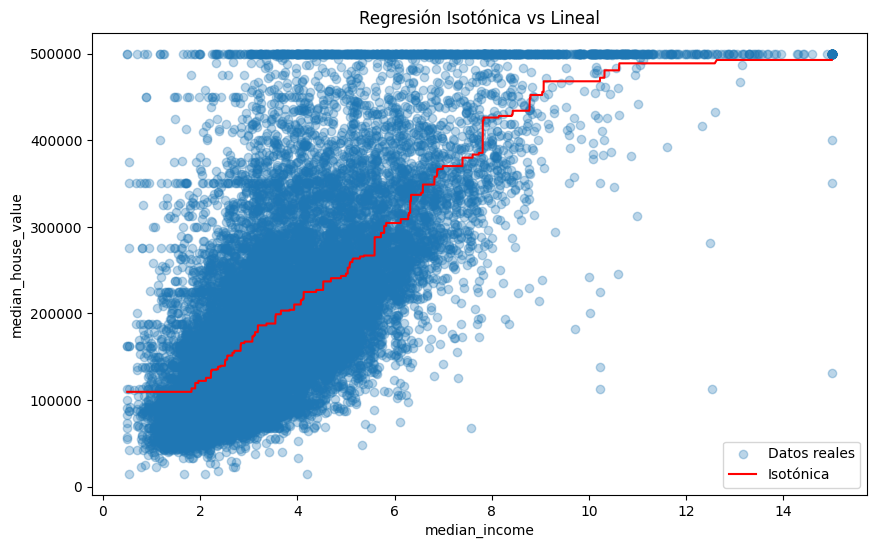

In [4]:
X_var = "median_income"
y_var = target 

data_iso = data[[X_var, y_var]].dropna()
data_iso = data_iso.sort_values(by=X_var)

X = data_iso[X_var].values
y = data_iso[y_var].values

iso = IsotonicRegression(increasing=True)

y_iso = iso.fit_transform(X, y)

plt.figure(figsize=(10,6))

plt.scatter(X, y, alpha=0.3, label='Datos reales')
plt.plot(X, y_iso, color='red', label='Isotónica')

plt.xlabel(X_var)
plt.ylabel(y_var)
plt.title('Regresión Isotónica vs Lineal')

plt.legend()
plt.savefig(images_dir / "regresion_isotonica1.svg")
plt.show()

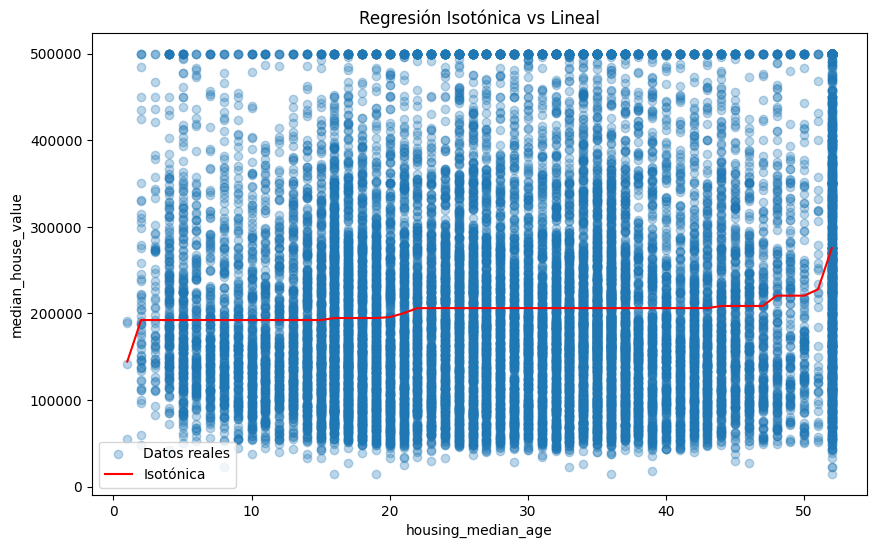

In [5]:
X_var = "housing_median_age"
y_var = target 

data_iso = data[[X_var, y_var]].dropna()
data_iso = data_iso.sort_values(by=X_var)

X = data_iso[X_var].values
y = data_iso[y_var].values

iso = IsotonicRegression(increasing=True)

y_iso = iso.fit_transform(X, y)

plt.figure(figsize=(10,6))

plt.scatter(X, y, alpha=0.3, label='Datos reales')
plt.plot(X, y_iso, color='red', label='Isotónica')

plt.xlabel(X_var)
plt.ylabel(y_var)
plt.title('Regresión Isotónica vs Lineal')

plt.legend()
plt.savefig(images_dir / "regresion_isotonica2.svg")
plt.show()

# Validación Cruzada

In [6]:
preprocessor_linear = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), var_cat),
    ('num', StandardScaler(), var_num)
])

preprocessor_tree = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), var_cat),
    ('num', 'passthrough', var_num)
])

X = data.drop(columns=target)
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
models_linear = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
}

models_tree = {
    "tree": DecisionTreeRegressor(max_depth=5, min_samples_split=10, random_state=42),
    "rnd_forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        oob_score=True,
        random_state=42,
        n_jobs=-1,
    ),
    "xgb_boost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
    ),
}

In [8]:
scores = {}

# Evaluación de modelos lineales sin validación cruzada

for name, model in models_linear.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor_linear),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    scores[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

for name, model in models_tree.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor_tree),
        ('model', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    scores[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}


pd.DataFrame(scores).T

,MAE,RMSE,R2
Linear,50100.146166,68779.911640,0.639579
Ridge,50106.312726,68785.771288,0.639517
Lasso,50100.225914,68779.974465,0.639578
tree,49807.663091,70424.584363,0.622136
rnd_forest,31660.468266,48528.060087,0.820579
xgb_boost,31624.734503,47070.187690,0.831197


In [9]:
results = {}

for name, model in models_linear.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor_linear),
        ('model', model)
    ])

    scores = cross_validate(
        pipe, X, y, cv=5,
        scoring={
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        }
    )

    results[name] = {
        'MAE': -scores['test_mae'].mean(),
        'RMSE': -scores['test_rmse'].mean(),
        'R2': scores['test_r2'].mean()
    }

for name, model in models_tree.items():
    pipe = Pipeline([
        ('preprocessing', preprocessor_tree),
        ('model', model)
    ])

    scores = cross_validate(
        pipe, X, y, cv=5,
        scoring={
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        }
    )

    results[name] = {
        'MAE': -scores['test_mae'].mean(),
        'RMSE': -scores['test_rmse'].mean(),
        'R2': scores['test_r2'].mean()
    }

pd.DataFrame(results).T

,MAE,RMSE,R2
Linear,54165.085907,73709.501909,0.559732
Ridge,54164.451932,73706.442929,0.559772
Lasso,54165.010064,73709.396356,0.559733
tree,60372.841265,83714.294909,0.415511
rnd_forest,55018.295466,76472.580463,0.510714
xgb_boost,48088.486825,66631.358636,0.638152


#### ¿Qué modelo es más estable?
• Los modelos Linear, Ridge y Lasso mostraron la menor fluctuación en sus métricas.
• Aunque su capacidad predictiva es moderada (𝑅2≈0.56), sus resultados son consistentes entre el entrenamiento y la validación cruzada.
• Son modelos de baja varianza, ideales si se busca una respuesta predecible frente a nuevos datos.

#### ¿Cuál presenta mayor varianza?
Random Forest presentó la caída más drástica en el desempeño. Su 𝑅2 descendió de 0.82 a 0.51 al aplicar validación cruzada.

# Ajuste de Hiperparámetros

## Lasso

In [10]:
alpha_grid = np.logspace(-4, 2, num=20)

results = {}

for alpha in alpha_grid:
    pipe = Pipeline([
        ('preprocessing', preprocessor_linear),
        ('model',Lasso(alpha = alpha))
    ])

    scores = cross_validate(
        pipe, X, y, cv=5,
        scoring={
            'mae': 'neg_mean_absolute_error',
            'rmse': 'neg_root_mean_squared_error',
            'r2': 'r2'
        }
    )

    results[alpha] = {
        'MAE': -scores['test_mae'].mean(),
        'RMSE': -scores['test_rmse'].mean(),
        'R2': scores['test_r2'].mean()
    }

pd.DataFrame(results).T.head(10)

,MAE,RMSE,R2
0.000100,54165.085830,73709.501802,0.559732
0.000207,54165.085748,73709.501688,0.559732
0.000428,54165.085580,73709.501454,0.559732
0.000886,54165.085230,73709.500968,0.559732
0.001833,54165.084509,73709.499964,0.559732
0.003793,54165.083017,73709.497889,0.559732
0.007848,54165.079932,73709.493597,0.559732
0.016238,54165.073552,73709.484719,0.559732
0.033598,54165.060371,73709.466382,0.559732
0.069519,54165.033126,73709.428462,0.559733


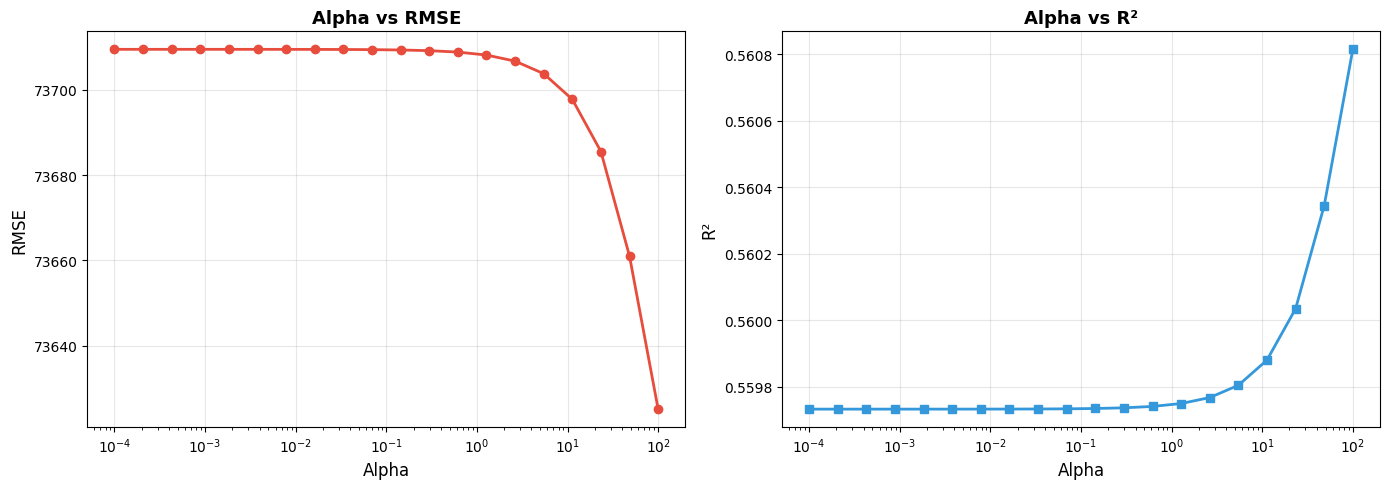

In [12]:
# Convertir results a DataFrame para facilitar la extracción de datos
results_df = pd.DataFrame(results).T

# Crear figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Alpha vs RMSE
ax1.plot(results_df.index, results_df['RMSE'], marker='o', linewidth=2, markersize=6, color='#e74c3c')
ax1.set_xlabel('Alpha', fontsize=12)
ax1.set_ylabel('RMSE', fontsize=12)
ax1.set_title('Alpha vs RMSE', fontsize=13, fontweight='bold')
ax1.set_xscale('log')
ax1.grid(True, alpha=0.3)

# Gráfico 2: Alpha vs R2
ax2.plot(results_df.index, results_df['R2'], marker='s', linewidth=2, markersize=6, color='#3498db')
ax2.set_xlabel('Alpha', fontsize=12)
ax2.set_ylabel('R²', fontsize=12)
ax2.set_title('Alpha vs R²', fontsize=13, fontweight='bold')
ax2.set_xscale('log')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(images_dir / "lasso_hyperparam_tuning.svg")
plt.show()

### Test

In [13]:
model_lasso = Pipeline([
    ("preprocessor", preprocessor_linear),
    ("model", Lasso(alpha=10e2))
])

model_lasso.fit(X_train, y_train)

y_pred = model_lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 50369.0702
RMSE: 69263.3625
R2: 0.6345


### Importancia de Variables mediante coeficientes

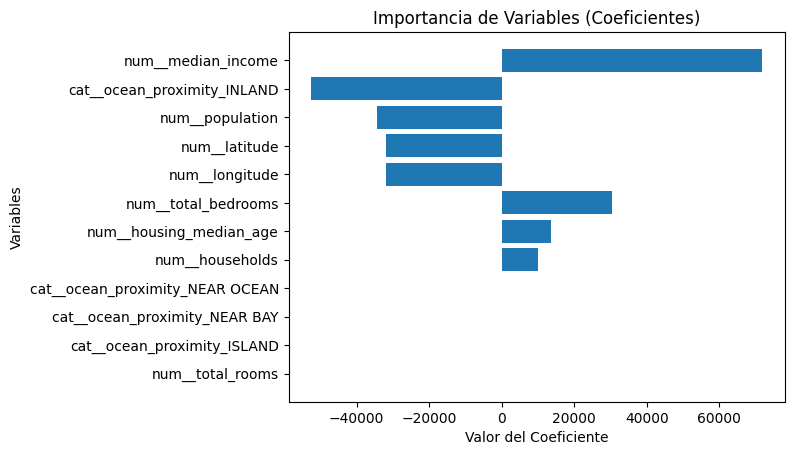

In [14]:
feature_names = model_lasso.named_steps['preprocessor'].get_feature_names_out()
coefficients = model_lasso.named_steps['model'].coef_

importance = pd.Series(coefficients, index=feature_names)
importance = importance.sort_values(key=abs, ascending=False)

# Crear DataFrame de importancia
importance = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': coefficients
})

# Ordenar por magnitud (importancia real)
importance['Importancia'] = importance['Coeficiente'].abs()
importance = importance.sort_values(by='Importancia', ascending=False)

# Tomar Top 15 (para que no quede ilegible)
top_n = 15
importance_top = importance.head(top_n)

# Gráfica
plt.figure()
plt.barh(importance_top['Variable'], importance_top['Coeficiente'])
plt.gca().invert_yaxis()
plt.title("Importancia de Variables (Coeficientes)")
plt.xlabel("Valor del Coeficiente")
plt.ylabel("Variables")
plt.savefig(images_dir / "lasso_importancia_variables.svg")
plt.show()

### Residuos y Predicciones

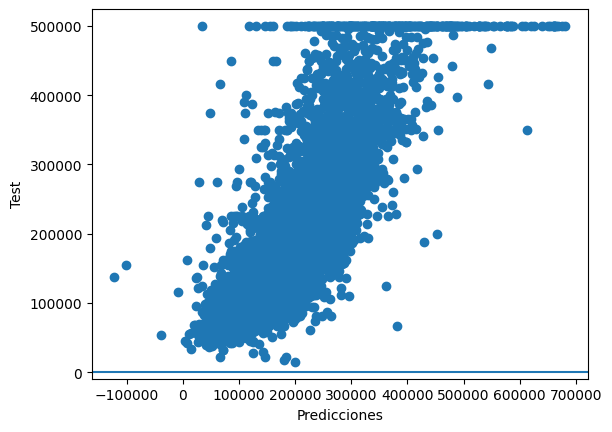

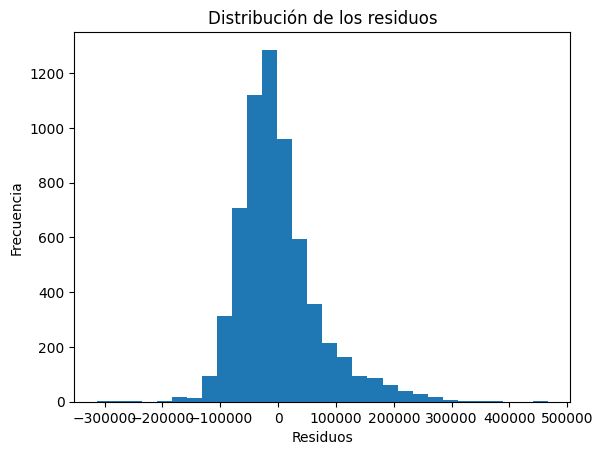

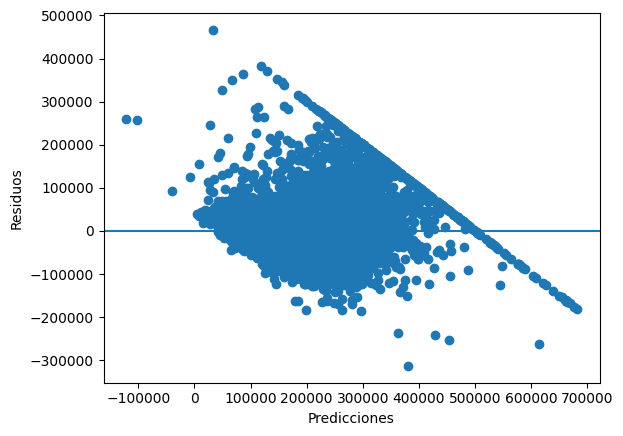

In [33]:
y_pred = model_lasso.predict(X_test)
residuos = y_test - y_pred

plt.scatter(y_pred, y_test)
plt.axhline(0)  # línea horizontal en 0
plt.xlabel("Predicciones")
plt.ylabel("Test")
plt.savefig(images_dir / "lasso_residuos.svg")
plt.show()


plt.hist(residuos, bins=30)
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.savefig(images_dir / "lasso_hist_residuos.svg")
plt.show()

plt.scatter(y_pred, residuos)
plt.axhline(0)  # línea horizontal en 0
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.savefig(images_dir / "lasso_residuos.svg")
plt.show()



#### Homocedasticidad:
Se observa heterocedasticidad.
La dispersión de los puntos no es constante a lo largo del eje de las Predicciones. Se nota que a medida que aumenta el valor predicho, la variabilidad de los errores cambia, formando una especie de embudo o abanico.

#### Patrón no aleatorio:
Presencia de patrones claros. Los residuos no están distribuidos de forma totalmente azarosa alrededor de la línea de cero.
Esto indica que existen relaciones no lineales en los datos que la regularización Lasso no logra capturar completamente, sugiriendo que un modelo no lineal o una transformación de variables podría mejorar el ajuste.

## Random Forest

In [16]:
param_grid = ParameterGrid({
    'rf__n_estimators': [100],
    'rf__max_features': ['sqrt', 0.3, 0.5],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_leaf': [1, 3, 5]
})

# ===================== #
# FUNCIÓN DE EVALUACIÓN #
# ===================== #

def eval_oob(X, y, params, verbose=False):
    
    model = Pipeline([
        ('prep', preprocessor_tree),
        ('rf', RandomForestRegressor(
            oob_score=True,
            n_jobs=1, 
            random_state=42
        ))
    ])
    
    model.set_params(**params)
    model.fit(X, y)
    
    rf_model = model.named_steps['rf']
    
    # OOB R2
    oob_r2 = rf_model.oob_score_
    
    # OOB RMSE
    y_oob = rf_model.oob_prediction_
    rmse_oob = np.sqrt(mean_squared_error(y, y_oob))
    
    if verbose:
        print(f"Modelo: {params} ✓")
    
    return {
        **params,
        'oob_r2': oob_r2,
        'oob_rmse': rmse_oob
    }

# ============== #
# PARALELIZACIÓN #
# ============== #

resultados = Parallel(n_jobs=cpu_count()-1)(
    delayed(eval_oob)(X_train, y_train, params)
    for params in param_grid
)

# ========== #
# RESULTADOS #
# ========== #

resultados = pd.DataFrame(resultados)

# Ordenar por RMSE 
resultados = resultados.sort_values('oob_rmse')

# Top resultados
resultados.head(10)

,rf__max_depth,rf__max_features,rf__min_samples_leaf,rf__n_estimators,oob_r2,oob_rmse
6,NaN,0.5,1,100,0.817031,49509.862569
7,NaN,0.5,3,100,0.816549,49575.114363
24,20.0,0.5,1,100,0.816530,49577.607367
25,20.0,0.5,3,100,0.814500,49851.116564
21,20.0,0.3,1,100,0.810309,50411.094205
18,20.0,sqrt,1,100,0.810309,50411.094205
26,20.0,0.5,5,100,0.810022,50449.223836
8,NaN,0.5,5,100,0.809730,50488.047235
3,NaN,0.3,1,100,0.807984,50719.151495
0,NaN,sqrt,1,100,0.807984,50719.151495


In [18]:
best_params = resultados.iloc[0].to_dict()

# Filtrar solo parámetros
best_params = {k: v for k, v in best_params.items() if k.startswith('rf__')}

def fix_types(params):
    for k, v in params.items():
        if isinstance(v, float) and v.is_integer():
            params[k] = int(v)
    return params

best_params = fix_types(best_params)
best_params["rf__max_depth"] = None

### Test

In [19]:
model = Pipeline([
    ("preprocessor", preprocessor_tree),
    ("rf", RandomForestRegressor(
        oob_score=True,
        n_jobs=1,
        random_state=42,
    ))
])

model.set_params(**best_params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2: {r2:.4f}")

MAE: 32165.1658
RMSE: 48933.7130
R2: 0.8176


### Importancia de las variables

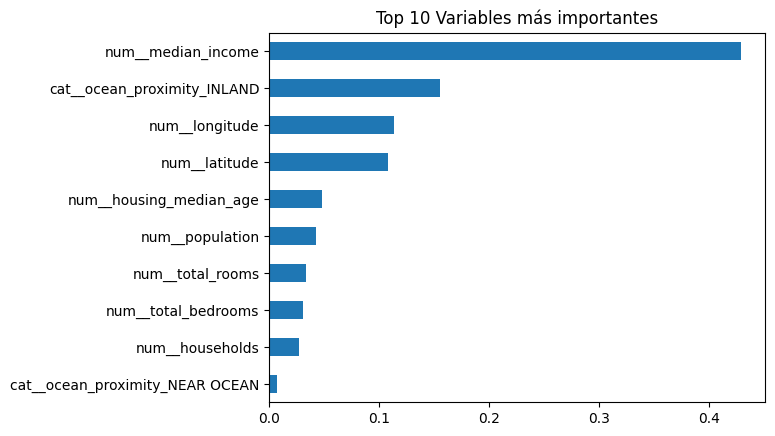

In [20]:
rf_model = model.named_steps['rf']
feature_names = model.named_steps['preprocessor'].get_feature_names_out()

importance = pd.Series(rf_model.feature_importances_, index=feature_names)
importance = importance.sort_values(ascending=False)

importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Variables más importantes")
plt.savefig(images_dir / "random_forest_importancia_variables.svg")
plt.show()

## XGBoost

In [21]:
from sklearn.model_selection import RandomizedSearchCV, RepeatedKFold

# Pipeline base
model = Pipeline([
    ('prep', preprocessor_tree),
    ('xgb', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=1   # Evitar paralelismo anidado y Cada modelo usa 1 núcleo
    ))
])

# n_jobs=1 (XGB)
# n_jobs=-1 (RandomizedSearch)

# Espacio de búsqueda
param_dist = {
    'xgb__n_estimators': randint(100, 500),
    'xgb__max_depth': randint(3, 10),
    'xgb__learning_rate': uniform(0.01, 0.2),
    'xgb__subsample': uniform(0.6, 0.4),        # [0.6, 1.0]
    'xgb__colsample_bytree': uniform(0.6, 0.4),
    'xgb__gamma': uniform(0, 2),
    'xgb__reg_alpha': uniform(0, 1),
    'xgb__reg_lambda': uniform(0.5, 2)
}

# Validación cruzada
cv = RepeatedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=40,   # puedes subir a 80 si tienes tiempo
    scoring='neg_root_mean_squared_error',
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
random_search.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros:")
print(random_search.best_params_)

print("\nMejor RMSE (CV):")
print(-random_search.best_score_)

best_model = random_search.best_estimator_

y_pred = best_model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("------------------")
print("Resultados en TEST")
print("------------------")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

Fitting 10 folds for each of 40 candidates, totalling 400 fits
Mejores hiperparámetros:
{'xgb__colsample_bytree': np.float64(0.6020739451095947), 'xgb__gamma': np.float64(1.2557888298972721), 'xgb__learning_rate': np.float64(0.04885479070240845), 'xgb__max_depth': 8, 'xgb__n_estimators': 499, 'xgb__reg_alpha': np.float64(0.050768531039396936), 'xgb__reg_lambda': np.float64(2.27323429790132), 'xgb__subsample': np.float64(0.6110467087494819)}

Mejor RMSE (CV):
45973.92961727393
------------------
Resultados en TEST
------------------
MAE : 29440.1940
RMSE: 44637.1416
R2  : 0.8482


### Importancia de variables

In [23]:
xgb_model = best_model.named_steps['xgb']
feature_names = model.named_steps['prep'].get_feature_names_out()

importance = pd.Series(rf_model.feature_importances_, index=feature_names)
importance = importance.sort_values(ascending=False)

importance.head(20)

num__median_income                 0.429740
cat__ocean_proximity_INLAND        0.155302
num__longitude                     0.113388
num__latitude                      0.107921
num__housing_median_age            0.048320
num__population                    0.042923
num__total_rooms                   0.033947
num__total_bedrooms                0.030794
num__households                    0.026991
cat__ocean_proximity_NEAR OCEAN    0.007375
cat__ocean_proximity_NEAR BAY      0.003002
cat__ocean_proximity_ISLAND        0.000297
dtype: float64

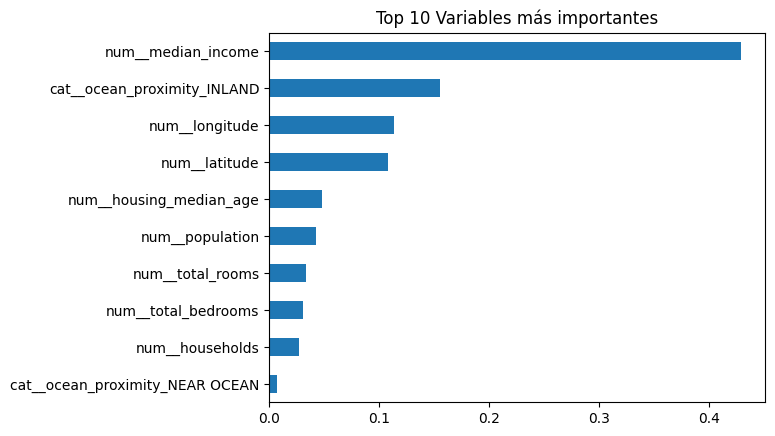

In [24]:
importance.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 Variables más importantes")
plt.savefig(images_dir / "xgboost_importancia_variables.svg")
plt.show()

### Residuos y predicciones

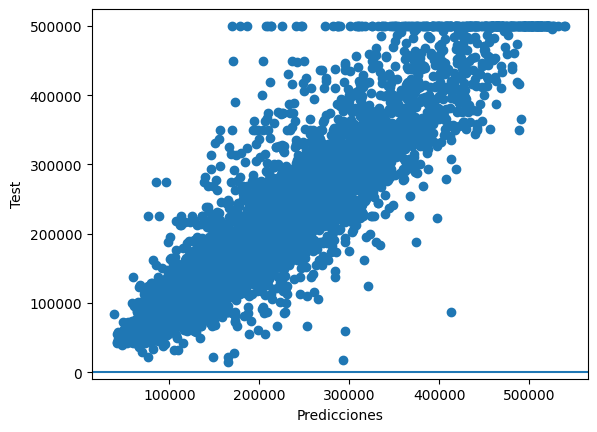

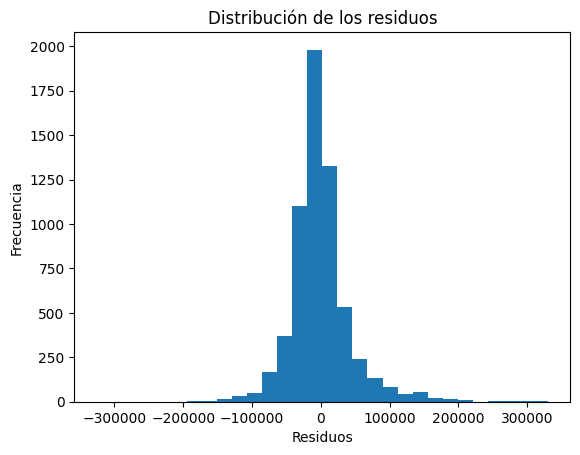

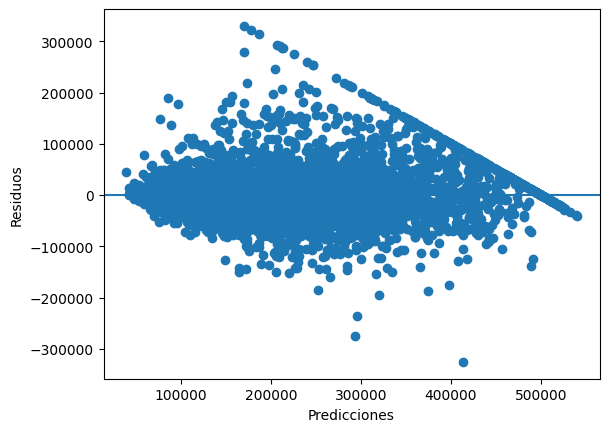

In [32]:
y_pred = best_model.predict(X_test)
residuos_xgboost = y_test - y_pred

import matplotlib.pyplot as plt

plt.scatter(y_pred, y_test)
plt.axhline(0)  # línea horizontal en 0
plt.xlabel("Predicciones")
plt.ylabel("Test")
plt.savefig(images_dir / "xgboost_residuos.svg")
plt.show()

plt.hist(residuos_xgboost, bins=30)
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.savefig(images_dir / "lasso_hist_residuos.svg")
plt.show()

plt.scatter(y_pred, residuos_xgboost)
plt.axhline(0)  # línea horizontal en 0
plt.xlabel("Predicciones")
plt.ylabel("Residuos")
plt.savefig(images_dir / "xgboost_residuos.svg")
plt.show()

#### Homocedasticidad:
Persiste una leve Heterocedasticidad.
Comparando este gráfico con el del Lasso, la nube de puntos es mucho más compacta y uniforme. Sin embargo, todavía se aprecia una ligera tendencia a que la dispersión de los errores aumente para valores de predicción más altos (entre 300,000 y 500,000).

#### Patrón no aleatorio:
La gran mayoría de los puntos se distribuyen de manera aleatoria y densa alrededor de la línea de cero, sugiere que el modelo ha capturado la mayor parte de la información lineal y no lineal.